# `bpe_overlap` Diagnosis — Bible Corpus

Focuses on understanding the `bpe_overlap` metric:
- **What the curve looks like** for close vs. distant language pairs
- **How `min_freq_fract` affects** the number of merges and the AUC
- **Asymmetric AUC matrix** across all 7 languages

`bpe_overlap(a → b)` measures how well BPE merge rules learned from corpus **a** compress corpus **b**.
The result is asymmetric: `a → b` ≠ `b → a` in general.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import urllib.request
import xml.etree.ElementTree as ET
from pathlib import Path
from itertools import permutations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from corpus_helpers.metrics import bpe_overlap

/Users/rastislavhronsky/Research/corpus-helpers/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download & parse (same setup as `bible_domain_distance.ipynb`)

In [2]:
LANGUAGES = {
    'en': 'English',
    'de': 'German',
    'nl': 'Dutch',
    'cs': 'Czech',
    'sk': 'Slovak',
    'pl': 'Polish',
    'fr': 'French',
}

RAW_BASE = 'https://raw.githubusercontent.com/christos-c/bible-corpus/master/bibles'
CACHE_DIR = Path('_bible_cache')
CACHE_DIR.mkdir(exist_ok=True)

def download(lang_code: str, lang_name: str) -> Path:
    dest = CACHE_DIR / f'{lang_code}.xml'
    if not dest.exists():
        url = f'{RAW_BASE}/{lang_name}.xml'
        print(f'Downloading {lang_name}...', end=' ', flush=True)
        urllib.request.urlretrieve(url, dest)
        print('done')
    else:
        print(f'{lang_name}: cached')
    return dest

def parse_bible(path: Path) -> list[bytes]:
    tree = ET.parse(path)
    return [
        (seg.text or '').strip().encode('utf-8')
        for seg in tree.iter('seg')
        if seg.text and seg.text.strip()
    ]

paths = {code: download(code, name) for code, name in LANGUAGES.items()}
corpora: dict[str, list[bytes]] = {}
for code, path in paths.items():
    corpora[code] = parse_bible(path)
    print(f'{code}: {len(corpora[code]):,} verses')

English: cached
German: cached
Dutch: cached
Czech: cached
Slovak: cached
Polish: cached
French: cached
en: 31,102 verses
de: 31,102 verses
nl: 29,004 verses
cs: 31,080 verses
sk: 31,172 verses
pl: 31,364 verses
fr: 31,102 verses


## 2. BPT_rel curves for representative pairs

Pick pairs that span the expected similarity range:
- **Very close**: cs → sk (Czech → Slovak, closely related Slavic)
- **Close**: de → nl (German → Dutch, West Germanic)
- **Medium**: en → de (English → German, both Germanic but more distant)
- **Cross-family**: fr → cs (Romance → Slavic)
- **Cross-family**: en → pl (Germanic → Slavic)

We also include the **self-curve** (a → a) as an upper-bound reference (AUC ≈ 1).

> **Runtime note**: each call trains two BPE tokenizers. Expect ~30–90 s per pair depending on hardware.

In [3]:
# (source, target, label, linestyle)
PAIRS = [
    ('cs', 'sk', 'cs → sk (very close)',  '-',  'tab:blue'),
    ('sk', 'cs', 'sk → cs (reverse)',      '--', 'tab:cyan'),
    ('de', 'nl', 'de → nl (close)',        '-',  'tab:green'),
    ('en', 'de', 'en → de (medium)',       '-',  'tab:orange'),
    ('fr', 'cs', 'fr → cs (cross-family)', '-',  'tab:red'),
    ('en', 'pl', 'en → pl (cross-family)', '--', 'tab:purple'),
    ('cs', 'cs', 'cs → cs (self)',         ':',  'black'),
]

DEFAULT_MFF = 1e-5  # start with a moderate value to keep merge counts manageable

results = {}
for src, tgt, label, ls, color in PAIRS:
    print(f'Running {label}...', end=' ', flush=True)
    res = bpe_overlap(corpora[src], corpora[tgt], min_freq_fract=DEFAULT_MFF, k_steps=30)
    results[(src, tgt)] = res
    print(f'AUC={res["auc"]:.4f}  n_merges={res["n_merges"]:,}  bpt_skyline={res["bpt_skyline"]:.3f}')

Running cs → sk (very close)... 





AUC=0.4254  n_merges=5,571  bpt_skyline=4.280
Running sk → cs (reverse)... 





AUC=0.3904  n_merges=5,522  bpt_skyline=4.250
Running de → nl (close)... 





AUC=0.2566  n_merges=5,087  bpt_skyline=4.780
Running en → de (medium)... 





AUC=0.2201  n_merges=4,995  bpt_skyline=4.875
Running fr → cs (cross-family)... 





AUC=0.1187  n_merges=5,327  bpt_skyline=4.250
Running en → pl (cross-family)... 





AUC=0.1239  n_merges=4,995  bpt_skyline=4.583
Running cs → cs (self)... 





AUC=0.7494  n_merges=5,571  bpt_skyline=4.250


In [10]:
np.log10(k_vals)

array([0.        , 0.30103   , 0.47712125, 0.60205999, 0.77815125,
       0.90308999, 1.04139269, 1.17609126, 1.30103   , 1.41497335,
       1.54406804, 1.68124124, 1.80617997, 1.93951925, 2.06818586,
       2.19589965, 2.32428246, 2.45484486, 2.58319877, 2.7126497 ,
       2.8419848 , 2.97081161, 3.10002573, 3.2291697 , 3.35850591,
       3.48756256, 3.61679049, 3.74593316])

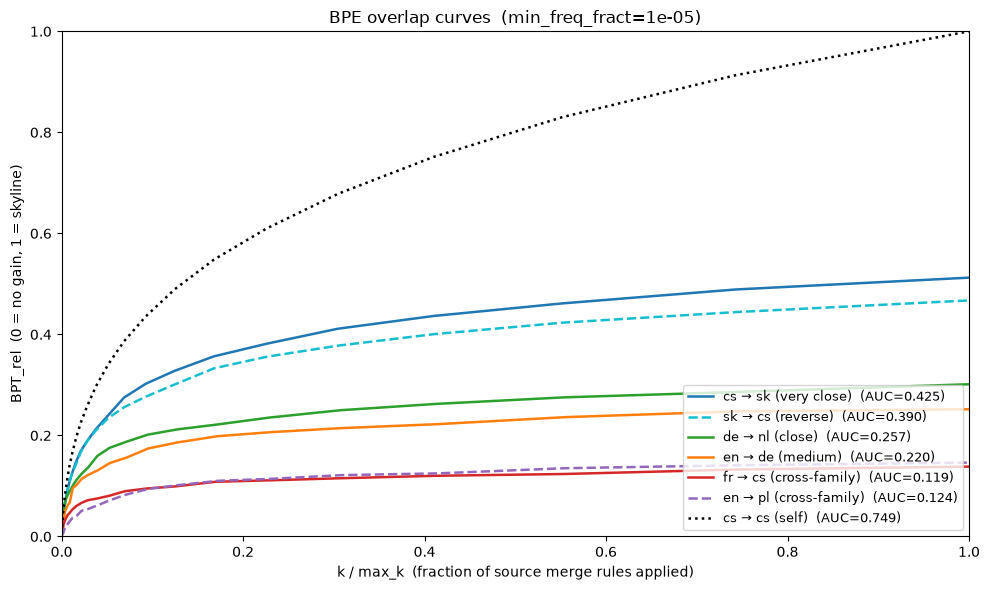

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

for src, tgt, label, ls, color in PAIRS:
    res = results[(src, tgt)]
    curve = res['curve']
    k_vals, bpt_rel = zip(*curve)
    k_norm = [k / res['n_merges'] for k in k_vals]
    auc = res['auc']
    ax.plot(k_norm, bpt_rel, ls, color=color, label=f'{label}  (AUC={auc:.3f})', linewidth=1.8)

ax.set_xlabel('k / max_k  (fraction of source merge rules applied)')
ax.set_ylabel('BPT_rel  (0 = no gain, 1 = skyline)')
ax.set_title(f'BPE overlap curves  (min_freq_fract={DEFAULT_MFF})')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# ax.set_xscale('log')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('bpe_overlap_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Effect of `min_freq_fract`

`min_freq_fract` controls how aggressively BPE is truncated:
- **Higher** → fewer merges (stops earlier, only high-frequency rules kept)
- **Lower** → more merges (includes rare/noisy rules)

We sweep it for one close pair (cs → sk) and one distant pair (fr → cs) to see how it changes the AUC and curve shape.

In [21]:
MFF_VALUES = [1e-4, 5e-5, 1e-5, 5e-6, 1e-6]
SWEEP_PAIRS = [('cs', 'sk', 'cs → sk'), ('fr', 'cs', 'fr → cs')]

sweep_results: dict[tuple, list[dict]] = {key: [] for key, _ in [(p[:2], p[2]) for p in SWEEP_PAIRS]}
sweep_results = {(src, tgt): [] for src, tgt, _ in SWEEP_PAIRS}

for src, tgt, label in SWEEP_PAIRS:
    for mff in MFF_VALUES:
        print(f'{label}  min_freq_fract={mff:.0e}...', end=' ', flush=True)
        res = bpe_overlap(corpora[src], corpora[tgt], min_freq_fract=mff, k_steps=30)
        sweep_results[(src, tgt)].append({'mff': mff, **res})
        print(f'AUC={res["auc"]:.4f}  n_merges={res["n_merges"]:,}')

cs → sk  min_freq_fract=1e-04... 





AUC=0.4816  n_merges=869
cs → sk  min_freq_fract=5e-05... 





AUC=0.4748  n_merges=1,543
cs → sk  min_freq_fract=1e-05... 





AUC=0.4254  n_merges=5,571
cs → sk  min_freq_fract=5e-06... 





AUC=0.4004  n_merges=9,751
cs → sk  min_freq_fract=1e-06... 





AUC=0.3120  n_merges=53,995
fr → cs  min_freq_fract=1e-04... 





AUC=0.1591  n_merges=829
fr → cs  min_freq_fract=5e-05... 





AUC=0.1458  n_merges=1,426
fr → cs  min_freq_fract=1e-05... 





AUC=0.1187  n_merges=5,327
fr → cs  min_freq_fract=5e-06... 





AUC=0.1099  n_merges=9,283
fr → cs  min_freq_fract=1e-06... 





AUC=0.0807  n_merges=37,999


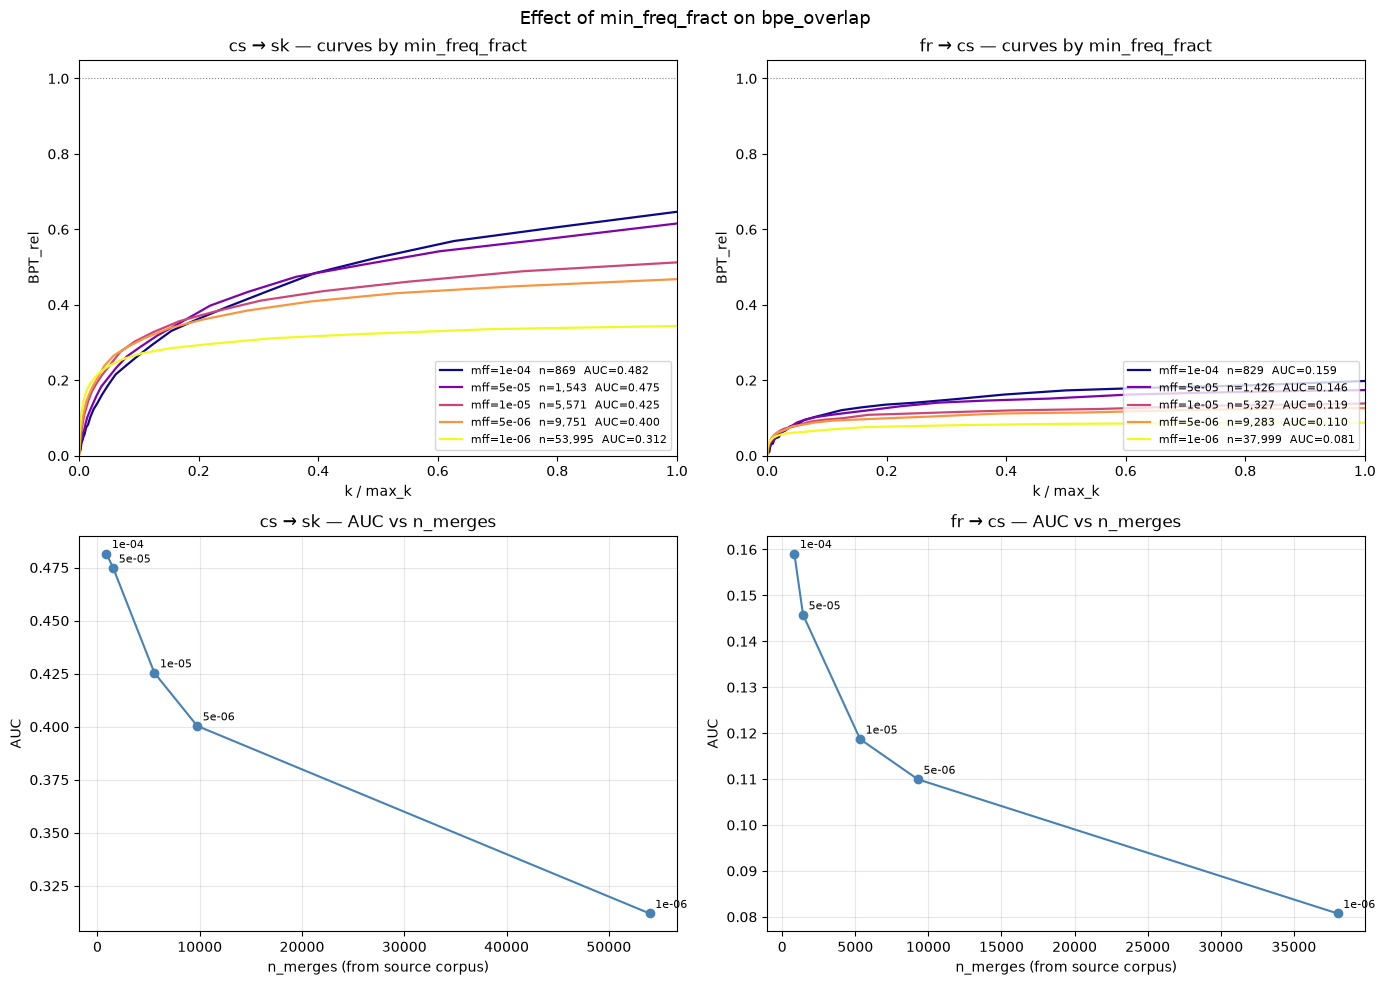

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cmap = plt.get_cmap('plasma', len(MFF_VALUES))

for col, (src, tgt, pair_label) in enumerate(SWEEP_PAIRS):
    ax_curve = axes[0, col]
    ax_auc   = axes[1, col]

    aucs, n_merges_list = [], []
    for idx, entry in enumerate(sweep_results[(src, tgt)]):
        curve = entry['curve']
        k_vals, bpt_rel = zip(*curve)
        k_norm = [k / entry['n_merges'] for k in k_vals]
        mff = entry['mff']
        auc = entry['auc']
        aucs.append(auc)
        n_merges_list.append(entry['n_merges'])
        ax_curve.plot(
            k_norm, bpt_rel,
            color=cmap(idx),
            label=f'mff={mff:.0e}  n={entry["n_merges"]:,}  AUC={auc:.3f}',
            linewidth=1.6,
        )

    ax_curve.axhline(1.0, color='grey', linewidth=0.8, linestyle=':')
    ax_curve.set_title(f'{pair_label} — curves by min_freq_fract')
    ax_curve.set_xlabel('k / max_k')
    ax_curve.set_ylabel('BPT_rel')
    ax_curve.legend(fontsize=8, loc='lower right')
    ax_curve.set_xlim(0, 1)
    ax_curve.set_ylim(bottom=0)

    # AUC vs n_merges
    ax_auc.plot(n_merges_list, aucs, 'o-', color='steelblue')
    for nm, auc, mff in zip(n_merges_list, aucs, MFF_VALUES):
        ax_auc.annotate(f'{mff:.0e}', (nm, auc), textcoords='offset points',
                        xytext=(4, 4), fontsize=8)
    ax_auc.set_title(f'{pair_label} — AUC vs n_merges')
    ax_auc.set_xlabel('n_merges (from source corpus)')
    ax_auc.set_ylabel('AUC')
    ax_auc.grid(True, alpha=0.3)

plt.suptitle('Effect of min_freq_fract on bpe_overlap', fontsize=13)
plt.tight_layout()
plt.savefig('bpe_overlap_mff_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Asymmetric AUC matrix across all 7 languages

Row = source (whose BPE merges are used), Column = target (which corpus is tokenized).
The diagonal is the self-AUC (upper bound).

**Asymmetry interpretation**: `a → b` > `b → a` means a's BPE generalises well to b but not vice versa,
which can happen when a has a richer merge table (larger corpus or denser vocabulary).

In [ ]:
LANG_CODES = list(LANGUAGES.keys())
N = len(LANG_CODES)
AUC_MFF = 1e-5  # use same value as section 2 for consistency

auc_mat = np.full((N, N), np.nan)
n_merges_mat = np.zeros((N, N), dtype=int)

total_runs = N * N
run = 0
for i, src in enumerate(LANG_CODES):
    for j, tgt in enumerate(LANG_CODES):
        run += 1
        print(f'[{run}/{total_runs}] {src} → {tgt}...', end=' ', flush=True)
        res = bpe_overlap(corpora[src], corpora[tgt], min_freq_fract=AUC_MFF, k_steps=25)
        auc_mat[i, j] = res['auc']
        n_merges_mat[i, j] = res['n_merges']
        print(f'AUC={res["auc"]:.4f}')

print('Done.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AUC heatmap
ax = axes[0]
sns.heatmap(
    auc_mat,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap='YlGn',
    xticklabels=LANG_CODES,
    yticklabels=LANG_CODES,
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
ax.set_title(f'bpe_overlap AUC (row=source, col=target)\nmin_freq_fract={AUC_MFF:.0e}')
ax.set_xlabel('Target corpus')
ax.set_ylabel('Source corpus (BPE trained on)')

# Asymmetry heatmap: (a→b) - (b→a)
ax2 = axes[1]
asym = auc_mat - auc_mat.T
sns.heatmap(
    asym,
    ax=ax2,
    annot=True,
    fmt='+.3f',
    cmap='RdBu_r',
    center=0,
    xticklabels=LANG_CODES,
    yticklabels=LANG_CODES,
    linewidths=0.5,
)
ax2.set_title('Asymmetry: AUC(row→col) − AUC(col→row)\nred = row generalises better to col than vice versa')
ax2.set_xlabel('Target')
ax2.set_ylabel('Source')

plt.tight_layout()
plt.savefig('bpe_overlap_auc_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. AUC summary table

In [ ]:
df_auc = pd.DataFrame(auc_mat, index=LANG_CODES, columns=LANG_CODES)
df_auc.index.name = 'source'
df_auc.columns.name = 'target'

# Off-diagonal sorted pairs
rows = []
for i, src in enumerate(LANG_CODES):
    for j, tgt in enumerate(LANG_CODES):
        if i != j:
            rows.append({'src→tgt': f'{src}→{tgt}', 'AUC': auc_mat[i,j], 'n_merges': n_merges_mat[i,j]})

df_pairs = pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)
print('All directed pairs ranked by AUC (high = source BPE compresses target well):')
df_pairs.style.background_gradient(subset=['AUC'], cmap='YlGn')